In [1]:
import os
import pyspark

# create a configuration container
conf = pyspark.SparkConf()
conf.set('spark.driver.memory','4g')
conf.set('spark.executor.memory','2g')

# start Spark
sc = pyspark.SparkContext(conf=conf)

#  get an entry point to the SQL package
spark = pyspark.SQLContext.getOrCreate(sc)

# show the session info
sc

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/10 23:45:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
/opt/conda/envs/bigdata/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


<SparkContext master=local[*] appName=pyspark-shell>

In [28]:
from pyspark.sql.functions import countDistinct, count, col, collect_list, size, coalesce, lit, from_unixtime, explode, length, split
import matplotlib.pyplot as plt
import pandas as pd
import math, json

# Data Loading

In [29]:
# data is very large, so only select the columns needed
posting_df = spark.read.option("header", "true").option("multiLine", "true").option("escape", '"')\
            .csv("data/postings.csv")\
            .select("job_id", "company_name", "title", "description", "location", "company_id", "skills_desc", "formatted_work_type","formatted_experience_level", "listed_time") 

In [30]:
posting_df.limit(2).toPandas()

,job_id,company_name,title,description,location,company_id,skills_desc,formatted_work_type,formatted_experience_level,listed_time
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",2774458.0,Requirements: \n\nWe are seeking a College or ...,Full-time,None,1713397508000.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",NaN,NaN,Full-time,None,1712857887000.0


In [31]:
company_industries_df = spark.read.option("header", "true").option("multiLine", "true").csv("data/companies/company_industries.csv")

# rename column so don't get confused with JOB industry
company_industries_df = company_industries_df.withColumnRenamed("industry", "company_industry")

company_industries_df.limit(2).toPandas()

,company_id,company_industry
0,391906,Book and Periodical Publishing
1,22292832,Construction


In [32]:
job_industries_df = spark.read.option("header", "true").option("multiLine", "true").csv("data/jobs/job_industries.csv")
job_industries_df.limit(2).toPandas()

,job_id,industry_id
0,3884428798,82
1,3887473071,48


In [33]:
job_industries_mappings_df = spark.read.option("header", "true").option("multiLine", "true").csv("data/mappings/industries.csv")

# rename column so don't get confused with company industry
job_industries_mappings_df = job_industries_mappings_df.withColumnRenamed("industry_name", "job_industry")

job_industries_mappings_df.limit(2).toPandas()

,industry_id,job_industry
0,1,Defense and Space Manufacturing
1,3,Computer Hardware Manufacturing


### Data Preprocessing (Partial)

In [34]:
# check for missing data 
print(company_industries_df.where(col("company_industry").isNull()).count())
print(job_industries_df.where(col("industry_id").isNull()).count())

0
0


In [35]:
print(job_industries_mappings_df.where(col("job_industry").isNull()).count())

# an industry id with no corresponding industry name, replace with "Other"
# don't want to drop it because will be used in join later 
job_industries_mappings_df = job_industries_mappings_df.fillna({"job_industry":"Other"})

34


In [36]:
# check for duplicate rows
print(posting_df.count() == posting_df.distinct().count())
print(company_industries_df.count() == company_industries_df.distinct().count())
print(job_industries_df.count() == job_industries_df.distinct().count())
print(job_industries_mappings_df.count() == job_industries_mappings_df.distinct().count())

True
True


True
True


In [37]:
# some of the extra metadata dataframes have multiple values for one id
company_industries_df.select(count("*").alias("total_rows"), countDistinct("company_id").alias("distinct_rows")).show()
job_industries_df.select(count("*").alias("total_rows"), countDistinct("job_id").alias("distinct_rows")).show()

# No repeats for the mappings
job_industries_mappings_df.select(count("*").alias("total_rows"), countDistinct("industry_id").alias("distinct_rows")).show()
posting_df.select(count("*").alias("total_rows"), countDistinct("job_id").alias("distinct_rows")).show()

+----------+-------------+
|total_rows|distinct_rows|
+----------+-------------+
|     24375|        24365|
+----------+-------------+

+----------+-------------+
|total_rows|distinct_rows|
+----------+-------------+
|    164808|       127125|
+----------+-------------+

+----------+-------------+
|total_rows|distinct_rows|
+----------+-------------+
|       422|          422|
+----------+-------------+



[Stage 351:>                                                        (0 + 1) / 1]

+----------+-------------+
|total_rows|distinct_rows|
+----------+-------------+
|    123849|       123849|
+----------+-------------+



In [38]:
# aggregate the dataframes so that the company_id is a unique identifier
# do this because it is not a mistake in data: makes sense that some companies can fit in 2 different industries
company_industries_df = company_industries_df.groupBy("company_id").agg(collect_list("company_industry").alias("company_industries"))
company_industries_df.limit(2).toPandas()
# do the same to job_industries after joining

,company_id,company_industries
0,10000,[Chemical Manufacturing]
1,10001,[Insurance]


In [39]:
posting_df.printSchema()

root
 |-- job_id: string (nullable = true)
 |-- company_name: string (nullable = true)
 |-- title: string (nullable = true)
 |-- description: string (nullable = true)
 |-- location: string (nullable = true)
 |-- company_id: string (nullable = true)
 |-- skills_desc: string (nullable = true)
 |-- formatted_work_type: string (nullable = true)
 |-- formatted_experience_level: string (nullable = true)
 |-- listed_time: string (nullable = true)



In [40]:
company_industries_df.printSchema()

root
 |-- company_id: string (nullable = true)
 |-- company_industries: array (nullable = false)
 |    |-- element: string (containsNull = false)



In [41]:
# make sure that company_id is consistent format because will use in join later
# company_industries_df already has company id as string, so its fine

# its current 'number.0', cast to float then into to remove the decimal point, the back to str
posting_df = posting_df.withColumn("company_id", col("company_id").cast("float").cast("long").cast("string")) 

## Joining

In [42]:
final_job_industries_df = job_industries_df.join(job_industries_mappings_df, on ='industry_id', how = 'inner')

# verify no missing data from join
print(final_job_industries_df.count())
print(job_industries_df.count())

# get rid of industry_id, not using it later
final_job_industries_df = final_job_industries_df.select("job_id", "job_industry")
final_job_industries_df.limit(2).toPandas()

164808
164808


,job_id,job_industry
0,3884428798,Book and Periodical Publishing
1,3887473071,Construction


In [43]:
# aggregate the dataframes so that the job_id is a unique identifier
# some jobs can be part of different industries

final_job_industries_df = final_job_industries_df.groupBy("job_id").agg(collect_list("job_industry").alias("job_industries"))
final_job_industries_df.limit(2).toPandas()

,job_id,job_industries
0,1014822088,[Software Development]
1,103254301,[Design Services]


In [44]:
# join the supporting dataframes with main posting_df
joined_posting_df = posting_df.join(company_industries_df, on = 'company_id', how = 'left')\
                    .join(final_job_industries_df, on = 'job_id', how = 'left')
joined_posting_df.limit(5).toPandas()

,job_id,company_id,company_name,title,description,location,skills_desc,formatted_work_type,formatted_experience_level,listed_time,company_industries,job_industries
0,1829192,NaN,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...","Fort Collins, CO",NaN,Full-time,None,1712857887000.0,None,None
1,10998357,64896720,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,"Cincinnati, OH",We are currently accepting resumes for FOH - A...,Full-time,None,1713277614000.0,None,[Restaurants]
2,23221523,766262,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,"New Hyde Park, NY",This position requires a baseline understandin...,Full-time,None,1712895812000.0,[Law Practice],[Law Practice]
3,35982263,NaN,NaN,Service Technician,Looking for HVAC service tech with experience ...,"Burlington, IA",NaN,Full-time,None,1713451943000.0,None,[Facilities Services]
4,921716,2774458,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,"Princeton, NJ",Requirements: \n\nWe are seeking a College or ...,Full-time,None,1713397508000.0,[Real Estate],[Real Estate]


In [45]:
# check that job_id is still a unique identifier: we did not create more rows with the joins
posting_df.select(count("*").alias("total_rows"), countDistinct("job_id").alias("distinct_rows")).show()
joined_posting_df.select(count("*").alias("total_rows"), countDistinct("job_id").alias("distinct_rows")).show()


+----------+-------------+
|total_rows|distinct_rows|
+----------+-------------+
|    123849|       123849|
+----------+-------------+



[Stage 391:>                                                        (0 + 1) / 1]

+----------+-------------+
|total_rows|distinct_rows|
+----------+-------------+
|    123849|       123849|
+----------+-------------+



# Data Preprocessing

In [46]:
# since there can be reposts, remove duplicates for description 
# don't want duplicated description for RAG
print(joined_posting_df.count())
joined_posting_df = joined_posting_df.dropDuplicates(subset = ["description"])
print(joined_posting_df.count())

123849


[Stage 402:============================>                            (2 + 2) / 4]

107828


In [47]:
# check for missing data
for column in joined_posting_df.columns: 
    print(f"Num of missing values in {column} : {joined_posting_df.where(col(column).isNull()).count()}")

Num of missing values in job_id : 0


Num of missing values in company_id : 1694


Num of missing values in company_name : 1696


Num of missing values in title : 0


Num of missing values in description : 1


...

Num of missing values in formatted_experience_level : 27107


Num of missing values in listed_time : 0


Num of missing values in company_industries : 16016


[Stage 484:======================>                                  (2 + 2) / 5]

Num of missing values in job_industries : 1423


In [48]:
# for missing values in description, drop it 
# the description will be the main part of the retrieval document, so if it is missing then the listing cannot provide much info
# there is also very few of it, so ok to drop

print(joined_posting_df.count())
joined_posting_df = joined_posting_df.dropna(subset = ["description"])
print(joined_posting_df.count()) # double check if the correct number of rows are dropped

107828


[Stage 498:============================>                            (2 + 2) / 4]

107827


company_id and company_name
* very small part of dataset is missing
* replace with ""
* will add this to the retrival doc, so using a empty string instead of something like "Unknown"

skills_desc
* replace with ""
* will add this to the retrival doc, so using a empty string 
* ok if this data is missing, data scraped from LinkedIn JSON files so info might be in job description instead (depending on how company entered it)

formatted_experience_level
* replace with "Unknown"
* not going to add this into retrival doc, using as metadata filter only
 
company_industries, job_industries
* replace with []
* metadata filter only

In [49]:
joined_posting_df = joined_posting_df.fillna({
    "company_id" : "",
    "company_name" : "",
    "skills_desc" : "",
    "formatted_experience_level" : "Unknown"
})

In [50]:
# doing the company_industries, job_industries because fillna doesn't like empty lists
joined_posting_df = joined_posting_df.withColumn("company_industries", coalesce(col("company_industries"), lit([])))\
                                     .withColumn("job_industries", coalesce(col("job_industries"), lit([])))

In [51]:
# check that there are no missing values 
for column in joined_posting_df.columns: 
    print(f"Num of missing values in {column} : {joined_posting_df.where(col(column).isNull()).count()}")

Num of missing values in job_id : 0
Num of missing values in company_id : 0
Num of missing values in company_name : 0


Num of missing values in title : 0


Num of missing values in description : 0


Num of missing values in location : 0
Num of missing values in skills_desc : 0


Num of missing values in formatted_work_type : 0
Num of missing values in formatted_experience_level : 0


[Stage 539:============================>                            (2 + 2) / 4]

Num of missing values in listed_time : 0
Num of missing values in company_industries : 0
Num of missing values in job_industries : 0


In [52]:
# convert listed time to datetime
# need to convert ms to seconds
joined_posting_df = joined_posting_df.withColumn("listed_time", from_unixtime(col("listed_time").cast("double")/1000, format = "yyyy-MM-dd"))
joined_posting_df.limit(2).toPandas()

,job_id,company_id,company_name,title,description,location,skills_desc,formatted_work_type,formatted_experience_level,listed_time,company_industries,job_industries
0,3905331854,3235,Boehringer Ingelheim,"US_Principal Specialist, Tech Support",\n\n\nDescription \n\n\n\n\n\nA Principal Spec...,"Gainesville, GA",,Full-time,Mid-Senior level,2024-04-18,[Pharmaceutical Manufacturing],[Pharmaceutical Manufacturing]
1,3905203241,3235,Boehringer Ingelheim,Molecular Parasitology Co-Op,\n\n\nDescription \n\nBoehringer Ingelheim is ...,"Athens, GA",,Full-time,Entry level,2024-04-18,[Pharmaceutical Manufacturing],[Pharmaceutical Manufacturing]


In [53]:
# make the dataset smaller to make compute easier

print(joined_posting_df.count())
joined_posting_df = joined_posting_df.sample(fraction = 0.3, withReplacement = False, seed = 1234)
print(joined_posting_df.count())

107827


[Stage 568:============================>                            (2 + 2) / 4]

32350


# EDA

In [54]:
# look at number of unique values, especially since so many categorical 
for column in joined_posting_df.columns: 
    print(f"Number of unique values for {column} : {joined_posting_df.select(col(column)).distinct().count()}")

Number of unique values for job_id : 32350


Number of unique values for company_id : 11453


Number of unique values for company_name : 11432


Number of unique values for title : 24050


Number of unique values for description : 32350


...

Number of unique values for formatted_experience_level : 7


Number of unique values for listed_time : 11


Number of unique values for company_industries : 143


[Stage 690:=============================================>           (4 + 1) / 5]

Number of unique values for job_industries : 2617


In [55]:
# look more at listed_time
joined_posting_df.describe("listed_time").show()

[Stage 704:==========================================>              (3 + 1) / 4]

+-------+-----------+
|summary|listed_time|
+-------+-----------+
|  count|      32363|
|   mean|       NULL|
| stddev|       NULL|
|    min| 2024-04-05|
|    max| 2024-04-19|
+-------+-----------+



Text(0.5, 1.0, 'Distribution of Job Post Date')

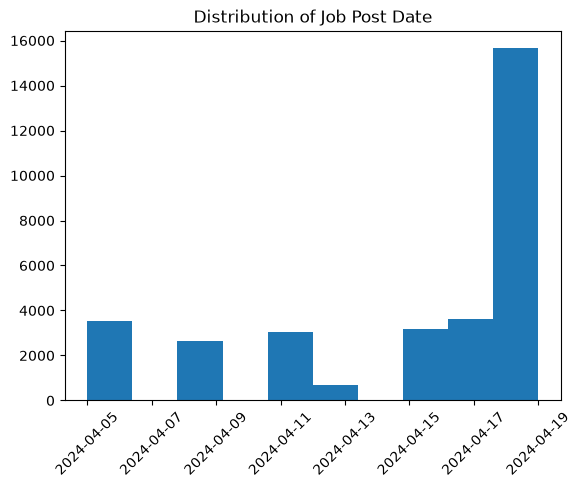

In [56]:
# look at listed_time, see when the jobs are posted
plt.hist(pd.to_datetime(joined_posting_df.select("listed_time").toPandas()["listed_time"]))
plt.xticks(rotation = 45)
plt.title("Distribution of Job Post Date")

Text(0.5, 1.0, 'Job Type')

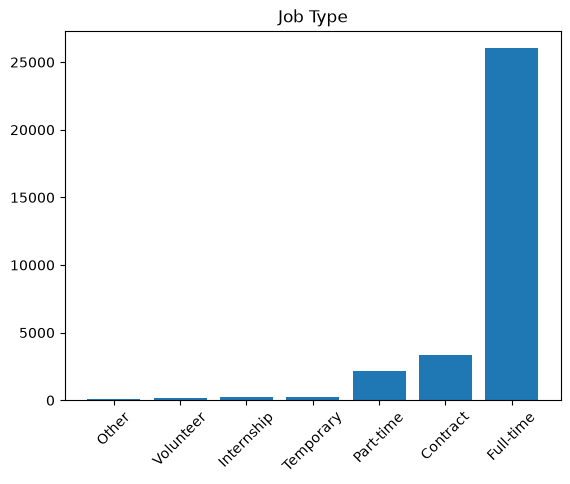

In [57]:
# look at work types
work_type_counts = joined_posting_df.groupBy("formatted_work_type").agg(count("*").alias("count")).orderBy("count").toPandas()

plt.bar(work_type_counts["formatted_work_type"], work_type_counts["count"].astype(int))
plt.xticks(rotation = 45)
plt.title("Job Type")

[Stage 726:============================>                            (2 + 2) / 4]

  formatted_experience_level  count
0                  Executive    332
1                 Internship    376
2                   Director    960
3                  Associate   2665
4                    Unknown   8150
5                Entry level   9045
6           Mid-Senior level  10835


Text(0.5, 1.0, 'Experience Level')

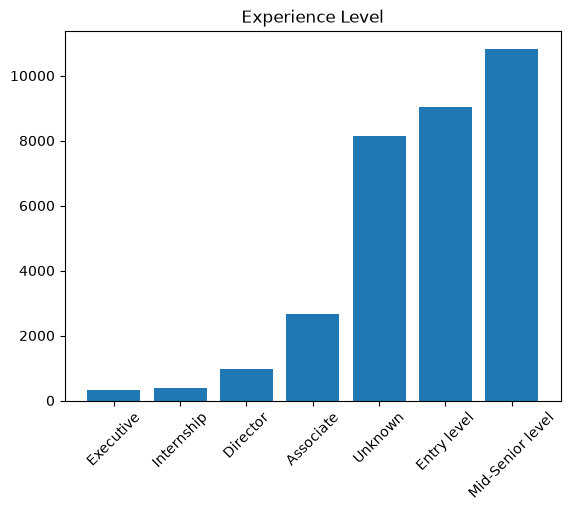

In [58]:
# look at experience level
experience_level_counts = joined_posting_df.groupBy("formatted_experience_level").agg(count("*").alias("count")).orderBy("count").toPandas()
print(experience_level_counts.head(20))

plt.bar(experience_level_counts["formatted_experience_level"], experience_level_counts["count"].astype(int))
plt.xticks(rotation = 45)
plt.title("Experience Level")

In [59]:
company_industries_df = joined_posting_df.select(explode("company_industries").alias("company_industries"))\
    .groupBy("company_industries").agg(count("*").alias("count")).orderBy("count", ascending = False).toPandas()
company_industries_df

,company_industries,count
0,Staffing and Recruiting,4416
1,Hospitals and Health Care,3469
2,IT Services and IT Consulting,2769
3,Retail,1665
4,Software Development,1243
...,...,...
131,Wholesale Import and Export,1
132,Animation and Post-production,1
133,Dairy Product Manufacturing,1
134,Nanotechnology Research,1


Text(0.5, 1.0, 'Company Industries')

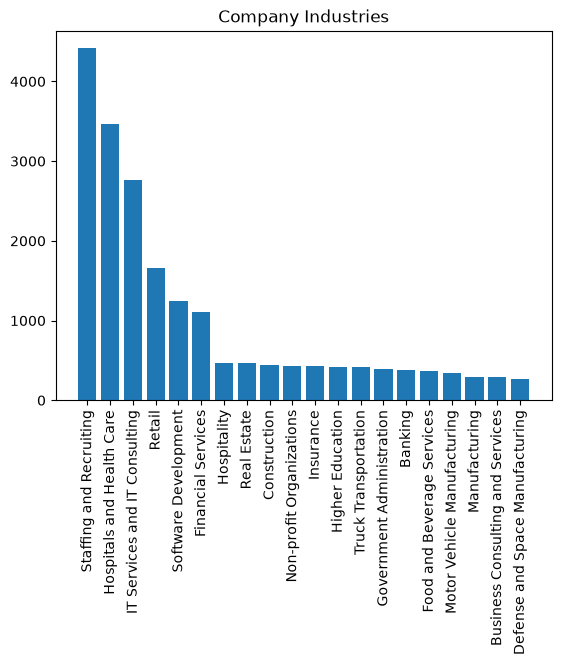

In [60]:
# too many industries so only showing top 20
# Note that some companies can be part of multiple industries
plt.bar(company_industries_df["company_industries"][:20], company_industries_df["count"][:20].astype(int))
plt.xticks(rotation = 90)
plt.title("Company Industries")

In [61]:
job_industries_df = joined_posting_df.select(explode("job_industries").alias("job_industries"))\
    .groupBy("job_industries").agg(count("*").alias("count")).orderBy("count", ascending = False).toPandas()
job_industries_df

,job_industries,count
0,Hospitals and Health Care,4897
1,IT Services and IT Consulting,2808
2,Staffing and Recruiting,2248
3,Retail,1979
4,Financial Services,1867
...,...,...
358,Landscaping Services,1
359,Graphic Design,1
360,Amusement Parks and Arcades,1
361,Wholesale Paper Products,1


Text(0.5, 1.0, 'Job Industries')

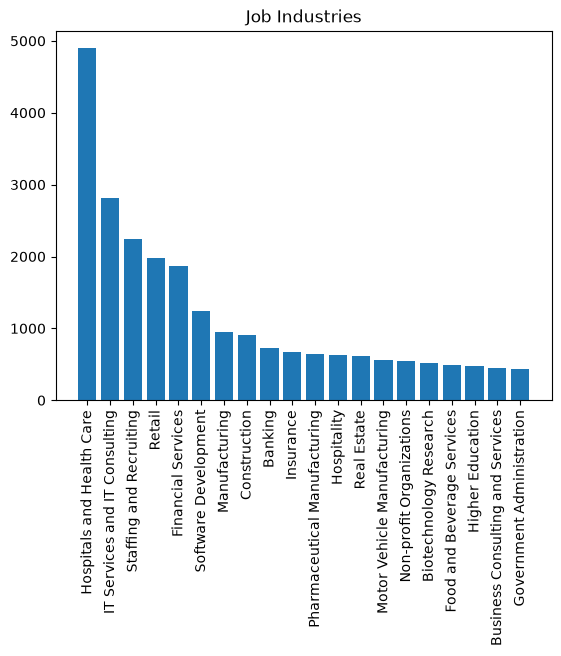

In [62]:
# too many industries so only showing top 20
# Note that some jobs can be part of multiple industries
plt.bar(job_industries_df["job_industries"][:20], job_industries_df["count"][:20].astype(int))
plt.xticks(rotation = 90)
plt.title("Job Industries")

       description_len
count     32350.000000
mean        518.519629
std         306.660305
min           1.000000
25%         289.000000
50%         471.000000
75%         694.000000
max        3400.000000


Text(0.5, 1.0, 'Description Length (in words)')

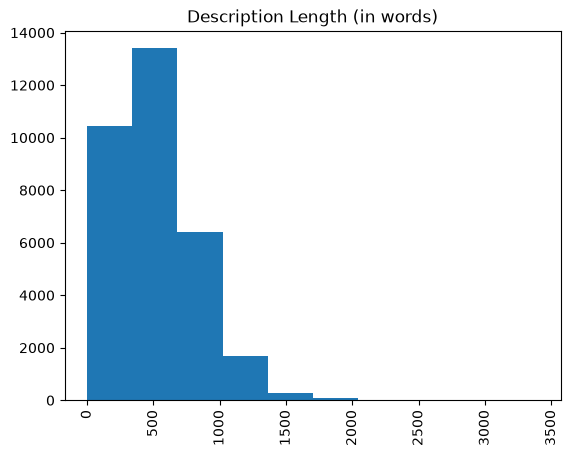

In [63]:
# length of descriptions (characters)
description_len_df = joined_posting_df.select(size(split(col("description"),r"\s+")).alias("description_len")).toPandas()
print(description_len_df.describe())

plt.hist(description_len_df["description_len"])
plt.xticks(rotation = 90)
plt.title("Description Length (in words)")

Insights
* very small date range, only representative of the distribution of job types in early April
* text length mostly 0 - 10000 chars
* Job and Company industries might have overlap between industries
  * Big 3 I see: Healthcare, IT, retail
  * staffing and recruiting (also there but I  think this is too general) 

# Creating Documents (export)

In [64]:
joined_posting_df_pd = joined_posting_df.select("job_id", "company_name", "title", "description", "location", \
                                                "skills_desc", "formatted_work_type", "formatted_experience_level").toPandas()

In [65]:
# experimented with different vals and decided on max_chunk_size and overlap_size, including overlaps
    # max_chunk_size including overlaps
# realized that some job descriptions are super short (like 5 words), so exclude those with a min_chunk_size

def chunking_fn(document, max_chunk_size = 200, overlap_size = 20, min_chunk_size=50):
    # split into words
    words = document.split()
    length = len(words)

    if length <=max_chunk_size:
        if length <= min_chunk_size:
            return []
        return [" ".join(words)]

    # divide into chunks
    # want to find the smallest number of even chunks so each is <= max_chunk_size
    # n chunks of size C with overlap O cover a total length of: L = (n*C) - (n-1)*O, where C <= max_chunk_size
        # each chunk will have overlap except for first chunk, so (n-1)*O
    # n = (L-O) / (C-O), with C = max_chunk_size
    # C = (L+ O(n-1))/n

    n = math.ceil((length - overlap_size) / (max_chunk_size - overlap_size)) # use max_chunk_size to find num chunks needed
    chunk_size = math.ceil((length + overlap_size * (n-1))/n) # redistribute the words evenly for each chunk instead of using max_chunk_size

    step = chunk_size - overlap_size       # how far to slide the window each time

    chunks = []
    start = 0

    while start < length:
        end = start + chunk_size
        chunks.append(" ".join(words[start:end]))
        if end >= length:
            break
        start += step
    return chunks
    

In [66]:
joined_posting_df_pd.shape

(32366, 8)

In [67]:
documents = []
for i in range(0, joined_posting_df_pd.shape[0]):    
    # Extract texts for embedding
    final_company_name = "" 
    final_skills = "" 
    
    if joined_posting_df_pd["company_name"][i] != "":  
        final_company_name = f"Company Name: {joined_posting_df_pd['company_name'][i]}"

    if joined_posting_df_pd["skills_desc"][i] != "":  
        final_skills = f"Skills: {joined_posting_df_pd['skills_desc'][i]}"

    full_text = f"{final_company_name}. Title: {joined_posting_df_pd['title'][i]}. Location: {joined_posting_df_pd['location'][i]}. Description: {joined_posting_df_pd['description'][i]}. {final_skills}"

    # chunk
    chunks = chunking_fn(full_text)

    for chunk in chunks:
        text = {}
        text['doc'] = chunk
        text['metadata'] ={
                'work_type': joined_posting_df_pd['formatted_work_type'][i],
                'experience_level': joined_posting_df_pd['formatted_experience_level'][i],
                'title': joined_posting_df_pd['title'][i],
                'job_id': joined_posting_df_pd['job_id'][i]
            } # metadata is the same for each chunk
        
        documents.append(text)

In [68]:
len(documents)

108804

In [69]:
# examine chunks 
lengths = [len(text["doc"].split()) for text in documents]
sample_indices = [
        lengths.index(min(lengths)),    # shortest chunk
        lengths.index(max(lengths)),    # longest chunk
        len(documents) // 4,           # one from early on
        len(documents) // 2,           # one from the middle
        (3 * len(documents)) // 4,     # one from later on
]

for n, i in enumerate(sample_indices, start=1):
    chunk = documents[i]
    print("=" * 70)
    print(f"Chunk {n}  {len(chunk['doc'].split())} words")
    print("-" * 70)
    print(chunk["doc"])
    print()

Chunk 1  51 words
----------------------------------------------------------------------
Company Name: Compri Consulting. Title: Project Manager - Healthcare. Location: Aurora, CO. Description: Demonstrated experience integrating into an existing project Required:Healthcare software implementation -Senior level software implementation & optimization project management skills. -Specific project management over testing, contingency planning and go-live. -Experience with Waterfall methodology.-Exceptional professionalism and emotional awareness. -PMP certification..

Chunk 2  200 words
----------------------------------------------------------------------
Company Name: AtkinsRéalis. Title: SmartPlant Administrator/ Designer. Location: United States. Description: Job Description Why join us? It’s an exciting time at AtkinsRéalis! We are rapidly growing in the US. Our company purpose is to build a better world for our planet and its people. We recognize the importance of making sure that ou

In [70]:
# using parquet because json takes up too much space

final_documents = pd.DataFrame(documents)
final_documents.to_parquet("documents.parquet")